In [1]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

mean (Ortalama): Görüntüdeki tüm hücrelerin ortalamasıdır. (Örn: radius_mean -> Hücrelerin ortalama yarıçapı ne kadar?)

se (Standard Error - Standart Hata): Hücreler birbirine ne kadar benziyor? Eğer hepsi aynı boydaysa bu sayı düşüktür, biri devasa biri minicikse bu sayı yüksektir. Düzensizliği gösterir.

worst (En Kötü / En Büyük): Görüntüdeki en büyük (veya en anormal) 3 hücrenin ortalamasıdır. Kanser teşhisinde genelde en kötü görünen hücreye bakılır çünkü bir tane bile kötü huylu hücre olması tehlikelidir.

In [3]:
# 1. Veri Yükleme
# Dosyada başlık olmadığı için header=None diyoruz.
data = pd.read_csv('wdbc.data', header=None)

# 2. Kolon İsimlerinin Oluşturulması
# wdbc.names dosyasındaki bilgiye göre 10 temel özellik var:
features_basic = [
    "radius", "texture", "perimeter", "area", "smoothness",
    "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension"
]

# Her özelliğin Mean, SE ve Worst versiyonları var
feature_names = []
for type_ in ["mean", "se", "worst"]:
    for feature in features_basic:
        feature_names.append(f"{feature}_{type_}")

# Tüm kolon isimleri: ID + Diagnosis + 30 Özellik   Diagnosisteki M VE B : M = Malignant (Kötü Huylu), B = Benign (İyi Huylu) M = 1 , B = 0
columns = ["id", "diagnosis"] + feature_names
data.columns = columns

# ID kolonu model için anlamsızdır (sadece kayıt numarası), onu atıyoruz.
data = data.drop(["id"], axis=1)

print(f"Veri Seti Boyutu: {data.shape}")
print(data.head())

Veri Seti Boyutu: (569, 31)
  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M        17.99         10.38          122.80     1001.0   
1         M        20.57         17.77          132.90     1326.0   
2         M        19.69         21.25          130.00     1203.0   
3         M        11.42         20.38           77.58      386.1   
4         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  ...  

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Encoding (M -> 1, B -> 0) alfabetil sıraya göre 0,1,2 sırayla verdiği için denk geldi işimize geldi
le = LabelEncoder()
data["diagnosis"] = le.fit_transform(data["diagnosis"])

# X (Özellikler) ve y (Hedef) ayrımı
X = data.drop("diagnosis", axis=1)
Y = data["diagnosis"]

# random_state sabit tutuyoruz ki sonuçlarımız her seferinde aynı olsun, karşılaştırma yapabilelim.
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=1907, stratify=Y)

sc = StandardScaler()
X_train_scaled = pd.DataFrame(sc.fit_transform(x_train), columns=X.columns)
X_test_scaled = pd.DataFrame(sc.transform(x_test), columns=X.columns)

In [5]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

def train_evaluate_xgb(X_tr, X_te, y_tr, y_te, description="Model"):
    model = XGBClassifier(
        n_estimators=95,     #karar ağacı sayısı
        max_depth=5,          #ağacın derinliği
        learning_rate=0.06,    #karar değiştirken bir önceki karara yüzde 90 güvenirim yeenisine yüzde 10 demek
        random_state=1907,
        eval_metric='logloss' #Puanlama Sistemi: Bu metrik, modelin sadece doğruyu bilmesini değil, emin olarak doğruyu bilmesini sağlar.
    )
    
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    
    acc = accuracy_score(y_te, preds) #doğruluk
    f1 = f1_score(y_te, preds)  #güvenilirlik
    
    print(f"--- {description} ---")
    print(f"Özellik Sayısı: {X_tr.shape[1]}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}\n")
    
    return acc, f1, model

# Baz Modeli Çalıştır
base_acc, base_f1, base_model = train_evaluate_xgb(X_train_scaled, X_test_scaled, y_train, y_test, "Baseline (Tüm Özellikler)")

--- Baseline (Tüm Özellikler) ---
Özellik Sayısı: 30
Accuracy: 0.9737
F1 Score: 0.9639



Genellikle VarianceThreshold, Scaling işleminden ÖNCE yapılır. Böylece gerçek verideki düşük varyanslıları yakalarsın

StandardScaler uyguladıktan sonra VarianceThreshold(0.1) kullanırsan, muhtemelen hiçbir şeyi atmaz (Sadece varyansı tam 0 olan, yani tamamen sabit sütunlar hariç). Çünkü her şeyin varyansı zaten 1 oldu.

In [6]:
#Düşük Varyanslı Özelliklerin Elenmesi (Variance Threshold)
from sklearn.feature_selection import VarianceThreshold

# Varyans eşiği (Örnek: 0.1 altındakileri at)
selector_var = VarianceThreshold(threshold=0.1)
selector_var.fit(X_train_scaled)

# Seçilen sütunları al
X_train_var = X_train_scaled.loc[:, selector_var.get_support()]
X_test_var = X_test_scaled.loc[:, selector_var.get_support()]

print(f"Varyans Filtresi Sonrası Kalan Özellik Sayısı: {X_train_var.shape[1]}")
# Modeli tekrar eğitip performansına bakacağız...

Varyans Filtresi Sonrası Kalan Özellik Sayısı: 30


Eğer "feature A" ile "feature B" %99 oranında birlikte hareket ediyorsa (korelasyon varsa), ikisini de modele sokmak gereksiz yük ve gürültü yaratır. Birini sileriz.

In [7]:
#Korelasyon Tabanlı Eleme:
def remove_highly_correlated_features(X_data, threshold=0.9):
    corr_matrix = X_data.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)) #ablonun sadece sağ üst üçgenini alır. Sol alt tarafı ve köşegeni (kendisiyle ilişkisini) siler. Böylece her çiftti sadece bir kez kontrol etmiş oluruz.
    
    # Eşik değerinden yüksek korelasyona sahip kolonları bul
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    print(f"Yüksek korelasyon nedeniyle atılacaklar ({len(to_drop)} adet): {to_drop}")
    return X_data.drop(columns=to_drop), to_drop

X_train_corr, dropped_corr = remove_highly_correlated_features(X_train_scaled, threshold=0.9)
X_test_corr = X_test_scaled.drop(columns=dropped_corr)


Yüksek korelasyon nedeniyle atılacaklar (10 adet): ['perimeter_mean', 'area_mean', 'concave_points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'concave_points_worst']


XGBoost eğitilirken hangi özelliğin ağaçlarda ne kadar sık kullanıldığına ve ne kadar bilgi kazancı (gain) sağladığına bakar. En az katkı sağlayanları atarız.

In [8]:
#Model Tabanlı (Feature Importance) Seçim
# Baz modelimizden önem derecelerini alalım
importances = base_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X_train_scaled.columns, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# Eşik değer belirleyelim (Örneğin: Önemi 0.01'den küçük olanları atalım)
selected_features_imp = feature_imp_df[feature_imp_df['Importance'] > 0.01]['Feature'].tolist()

X_train_imp = X_train_scaled[selected_features_imp]
X_test_imp = X_test_scaled[selected_features_imp]

print(f"Model Önemi Filtresi Sonrası Kalan Özellik Sayısı: {len(selected_features_imp)}")

Model Önemi Filtresi Sonrası Kalan Özellik Sayısı: 18


In [9]:
#ABLATION ÇALIŞMASI (EN KRİTİK 5 ÖZELLİK TESTİ)
# Önce en iyi modelimizden (Baseline) en önemli 5 özelliği öğrenelim
importances = base_model.feature_importances_
feat_imp = pd.Series(importances, index=X_train_scaled.columns).sort_values(ascending=False)
top_5_features = feat_imp.head(5).index.tolist()

print(f"\n--- ABLATION TESTİ BAŞLIYOR ---")
print(f"Modelin Vazgeçilmez Sandığı Top 5 Özellik: {top_5_features}\n")

# DÖNGÜ: Her seferinde bu 5 özellikten BİRİNİ çıkarıp modeli zorluyoruz
# Bakalım "Yarıçap" olmadan da kanseri bulabilecek mi?
for feature_to_drop in top_5_features:
    # 1. Özelliği At (Drop)
    # DİKKAT: Orijinal scaled veriden atıyoruz
    X_train_abl = X_train_scaled.drop(columns=[feature_to_drop])
    X_test_abl = X_test_scaled.drop(columns=[feature_to_drop])
    
    # 2. Eksik özellikle dene (Modeli Eğit)
    # Fonksiyonu tekrar çağırıyoruz
    acc, f1, _ = train_evaluate_xgb(
        X_train_abl, 
        X_test_abl, 
        y_train, 
        y_test, 
        f"Ablation: -{feature_to_drop} Çıkarıldı"
    )


--- ABLATION TESTİ BAŞLIYOR ---
Modelin Vazgeçilmez Sandığı Top 5 Özellik: ['perimeter_worst', 'area_worst', 'concave_points_worst', 'concave_points_mean', 'radius_worst']

--- Ablation: -perimeter_worst Çıkarıldı ---
Özellik Sayısı: 29
Accuracy: 0.9825
F1 Score: 0.9762

--- Ablation: -area_worst Çıkarıldı ---
Özellik Sayısı: 29
Accuracy: 0.9737
F1 Score: 0.9639

--- Ablation: -concave_points_worst Çıkarıldı ---
Özellik Sayısı: 29
Accuracy: 0.9737
F1 Score: 0.9647

--- Ablation: -concave_points_mean Çıkarıldı ---
Özellik Sayısı: 29
Accuracy: 0.9561
F1 Score: 0.9425

--- Ablation: -radius_worst Çıkarıldı ---
Özellik Sayısı: 29
Accuracy: 0.9649
F1 Score: 0.9524




--- Grafik İçin Veriler Toplanıyor ---
--- Ablation: -perimeter_worst ---
Özellik Sayısı: 29
Accuracy: 0.9825
F1 Score: 0.9762

--- Ablation: -area_worst ---
Özellik Sayısı: 29
Accuracy: 0.9737
F1 Score: 0.9639

--- Ablation: -concave_points_worst ---
Özellik Sayısı: 29
Accuracy: 0.9737
F1 Score: 0.9647

--- Ablation: -concave_points_mean ---
Özellik Sayısı: 29
Accuracy: 0.9561
F1 Score: 0.9425

--- Ablation: -radius_worst ---
Özellik Sayısı: 29
Accuracy: 0.9649
F1 Score: 0.9524


       FİNAL SONUÇ TABLOSU       
                   Yöntem  Accuracy  F1-Score
Baseline (Tüm Özellikler)  0.973684  0.963855
         -perimeter_worst  0.982456  0.976190
              -area_worst  0.973684  0.963855
    -concave_points_worst  0.973684  0.964706
     -concave_points_mean  0.956140  0.942529
            -radius_worst  0.964912  0.952381


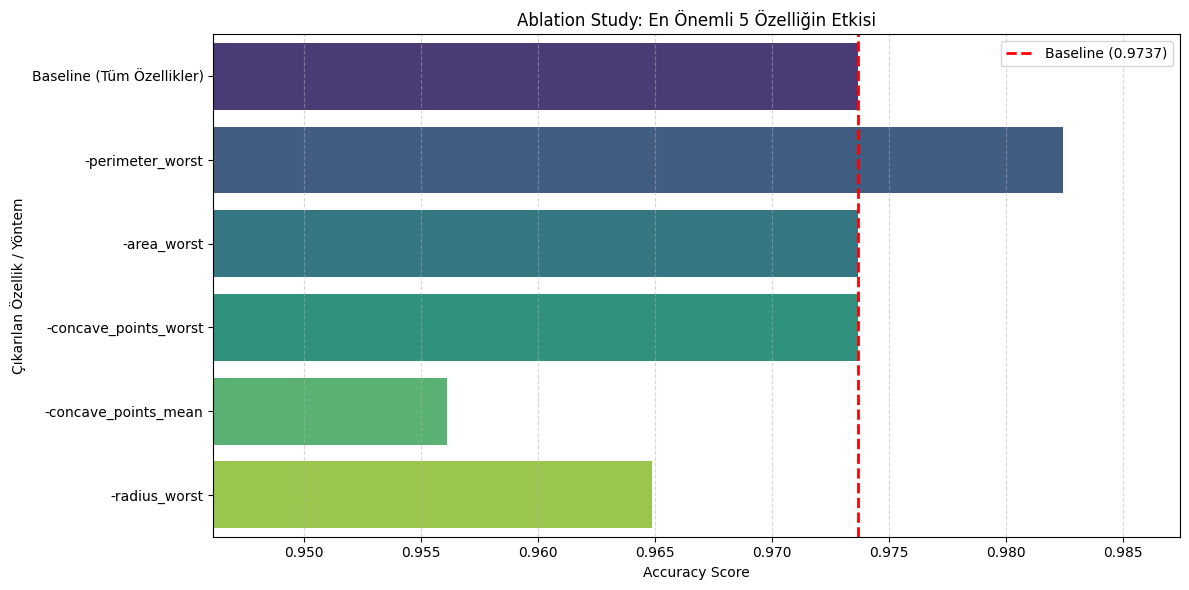

In [ ]:
results = []

# 2. Baseline Sonucu listeye eklenir.
results.append({
    "Yöntem": "Baseline (Tüm Özellikler)",
    "Accuracy": base_acc,  
    "F1-Score": base_f1
})

# 3. Ablation Döngüsü (Grafik verisi toplamak için çalıştırıyoruz)

print("\n--- Grafik İçin Veriler Toplanıyor ---")

for feature in top_5_features:
    # Özelliği çıkar
    X_train_abl = X_train_scaled.drop(columns=[feature])
    X_test_abl = X_test_scaled.drop(columns=[feature])
    
    # Modeli eğit (Sonuçları al)
    acc, f1, _ = train_evaluate_xgb(
        X_train_abl, 
        X_test_abl, 
        y_train, 
        y_test, 
        description=f"Ablation: -{feature}"
    )
    
    # SONUCU LİSTEYE KAYDET (Eksik olan kısım burasıydı)
    results.append({
        "Yöntem": f"-{feature}", # Grafikte kısa görünsün diye sadece özellik adı
        "Accuracy": acc,
        "F1-Score": f1
    })

results_df = pd.DataFrame(results)

print("\n" + "="*40)
print("       FİNAL SONUÇ TABLOSU       ")
print("="*40)
print(results_df.to_string(index=False))

# Grafiği Çiz
plt.figure(figsize=(12, 6))

# Baseline çizgisini (Kırmızı Kesikli Çizgi) ekle
baseline_val = results_df.iloc[0]['Accuracy']
plt.axvline(x=baseline_val, color='red', linestyle='--', linewidth=2, label=f'Baseline ({baseline_val:.4f})')

# Bar Plot Çizimi
sns.barplot(data=results_df, x='Accuracy', y='Yöntem', palette='viridis', hue='Yöntem', legend=False)

# Grafik Ayarları
plt.title("Ablation Study: En Önemli 5 Özelliğin Etkisi")
plt.xlabel("Accuracy Score")
plt.ylabel("Çıkarılan Özellik / Yöntem")

min_acc = results_df['Accuracy'].min()
max_acc = results_df['Accuracy'].max()
plt.xlim(min_acc - 0.01, max_acc + 0.005) 

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()